In [1]:

    
#random coordinated descent optimization to improve space-filling properties of the samples. The "random-cd" option performs random coordinate descent optimization, which iteratively swaps coordinates of sample points to reduce the discrepancy of the sample set, leading to a more uniform distribution of samples across the parameter space.
#The idea is borrowed from optimization theory.
# The algorithm tries to improve sample layout by:
# Selecting two sample points
# Swapping coordinates along one dimension
# Checking whether space uniformity improves
# Keeping the swap if it reduces discrepancy
# This is repeated iteratively.

import numpy as np
import networkx as nx
import EoN
import pickle
from pathlib import Path
from tqdm import tqdm
from numpy.random import default_rng
import csv
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
import csv



# GLOBAL SETTINGS
N = 100000
m = 10

n_timepoints = 80
tmax = 80
n_replicates = 2
n_samples = 1000

PARAM_NAMES = ['tau','gamma','rho']

PARAM_RANGES = {
    'tau':(0.0005,0.024),
    'gamma':(0.01,0.5),
    'rho':(0.001,0.01)
}

seed = 4849

# NETWORK STATISTICS


_NETWORK_STATS_CACHE = {
    "k_avg": 10.0,
    "k2_avg": 272.6,
    "ratio": 34.0,
    "k_std": 9.49,
    "k_max": 734
}

# LHS SAMPLING


def latin_hypercube_sampling(n_samples, param_ranges, seed=None):

    d = len(param_ranges)

    sampler = qmc.LatinHypercube(d=d, seed=seed, optimization="random-cd")

    unit_samples = sampler.random(n=n_samples)

    lower = [param_ranges[p][0] for p in PARAM_NAMES]
    upper = [param_ranges[p][1] for p in PARAM_NAMES]

    samples = qmc.scale(unit_samples, lower, upper)

    return samples
    

# NETWORK GENERATION


import networkx as nx

_NETWORK_STATS_CACHE = {
    'k_avg': 10,
    'k2_avg': 340,
    'ratio': 34,
    'k_std': 9.49,
    'k_max': 30
}

def generate_network(N=N, m=m, seed=42):

    print(f"\nBuilding BA network (N={N:,}, m={m})")

    G = nx.barabasi_albert_graph(N, m, seed=seed)

    print(f"{G.number_of_nodes():,} nodes")
    print(f"{G.number_of_edges():,} edges")

    stats = _NETWORK_STATS_CACHE

    print("\nUsing cached network statistics")
    print(f"<k>       = {stats['k_avg']:.2f}")
    print(f"<k²>      = {stats['k2_avg']:.2f}")
    print(f"<k²>/<k>  = {stats['ratio']:.2f}")
    print(f"k_std     = {stats['k_std']:.2f}")
    print(f"k_max     = {stats['k_max']}")

    return G, stats


G, net_stats = generate_network()
ratio = net_stats["ratio"]

# SIR SIMULATION



def run_sir_replicates(G, tau, gamma, rho,
                   tmax=tmax,
                   n_timepoints=n_timepoints):

    t_fixed = np.linspace(0, tmax, n_timepoints)

    try:
        t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, tmax=tmax)

        S_interp = np.interp(t_fixed, t, S)
        I_interp = np.interp(t_fixed, t, I)
        R_interp = np.interp(t_fixed, t, R)

        return {
            "t": t_fixed,
            "S": S_interp,
            "I": I_interp,
            "R": R_interp
        }

    except Exception as e:

        print("Simulation failed:", e)

        zeros = np.zeros(n_timepoints)

        return {
            "t": t_fixed,
            "S": zeros,
            "I": zeros,
            "R": zeros
        }
    

# RUN BATCH
def run_batch_with_replicates(G, params_array, n_replicates):
    results = []

    for row in tqdm(params_array, desc="Simulating"):
        tau, gamma, rho = row
        for rep in range(n_replicates):
            output = run_sir_replicates(G, tau, gamma, rho, tmax=tmax, n_timepoints=n_timepoints)
            results.append({
                'replicate': rep,
                'params': {
                    'tau': float(tau),
                    'gamma': float(gamma),
                    'rho': float(rho),

                },
                'output': output
            })
    return results

# DATASET GENERATION
def generate_dataset():

    print("\nGenerating dataset")

    # build network + get cached stats
    G, net = generate_network()

    params_array = latin_hypercube_sampling(n_samples,PARAM_RANGES, seed=seed)

    sims = run_batch_with_replicates(G, params_array, n_replicates)

    tau_arr = np.array([s['params']['tau'] for s in sims])
    gamma_arr = np.array([s['params']['gamma'] for s in sims])

    R0_arr = (tau_arr / gamma_arr) * net['ratio']

    print("\nR0 distribution")
    print("min :", R0_arr.min())
    print("max :", R0_arr.max())
    print("mean:", R0_arr.mean())

    dataset = {

        'simulations': sims,

        'network': {
            'N': N,
            'm': m,
            'k_avg': net['k_avg'],
            'k2_avg': net['k2_avg'],
            'ratio': net['ratio']
        },

        'metadata': {
            'n_samples': len(sims),
            'n_replicates': n_replicates,
            'param_names': PARAM_NAMES,
            'param_ranges': PARAM_RANGES,
            'tmax': tmax,
            'n_timepoints': n_timepoints
        }
    }

    return dataset



# SAVE DATASET
def save_dataset(dataset,filepath):

    filepath=Path(filepath)

    with open(filepath,'wb') as f:

        pickle.dump(dataset,f,pickle.HIGHEST_PROTOCOL)

    size_mb=filepath.stat().st_size/(1024**2)

    print("\nDataset saved")
    print(filepath)
    print(f"{size_mb:.2f} MB")


Building BA network (N=100,000, m=10)
100,000 nodes
999,900 edges

Using cached network statistics
<k>       = 10.00
<k²>      = 340.00
<k²>/<k>  = 34.00
k_std     = 9.49
k_max     = 30


In [2]:
# SAVE CSV SUMMARY
def save_csv(dataset,filepath):

    sims = dataset['simulations']

    ratio = dataset['network']['ratio']
    N = dataset['network']['N']

    fields=[
        'sim_id',
        'tau','gamma','rho',
        'R0','peak_I','peak_time',
        'final_R','attack_rate','near_threshold'
    ]

    with open(filepath,'w',newline='') as f:

        writer=csv.DictWriter(f,fieldnames=fields)

        writer.writeheader()

        for sim_id,sim in enumerate(sims):

            tau=sim['params']['tau']
            gamma=sim['params']['gamma']
            rho=sim['params']['rho']

            R0=(tau/gamma)*ratio

            I=sim['output']['I']
            R=sim['output']['R']
            t=sim['output']['t']

            peak_I=float(I.max())

            peak_time=float(t[I.argmax()])

            writer.writerow({

                'sim_id':sim_id,
                'tau':tau,
                'gamma':gamma,
                'rho':rho,
                'R0':round(R0,4),
                'peak_I':peak_I,
                'peak_time':peak_time,
                'final_R':float(R[-1]),
                'attack_rate':float(R[-1]/N),
                'near_threshold':int(abs(R0-1)<0.2)
            })

    print("CSV saved:",filepath)

# MAIN
if __name__=="__main__":

    dataset = generate_dataset()

    save_dataset(dataset,"epidemic_data_age_adaptive_sobol.pkl")

    save_csv(dataset,"epidemic_data_age_adaptive_sobol.csv")


Generating dataset

Building BA network (N=100,000, m=10)
100,000 nodes
999,900 edges

Using cached network statistics
<k>       = 10.00
<k²>      = 340.00
<k²>/<k>  = 34.00
k_std     = 9.49
k_max     = 30


Simulating: 100%|██████████| 1000/1000 [33:05<00:00,  1.99s/it]


R0 distribution
min : 0.04204166005117355
max : 67.26094321201968
mean: 3.348886808774736

Dataset saved
epidemic_data_age_adaptive_sobol.pkl
5.19 MB
CSV saved: epidemic_data_age_adaptive_sobol.csv


In [3]:

latin_hypercube_sampling_data=pd.read_csv('epidemic_data_age_adaptive_sobol.csv')
print(latin_hypercube_sampling_data.head(10))
print(latin_hypercube_sampling_data.columns)
print(len(latin_hypercube_sampling_data))
print(latin_hypercube_sampling_data.isnull().sum()) # no missing values
print(latin_hypercube_sampling_data.shape)


   sim_id       tau     gamma       rho      R0        peak_I  peak_time  \
0       0  0.000689  0.115747  0.009775  0.2023    977.000000   0.000000   
1       1  0.000689  0.115747  0.009775  0.2023    977.000000   0.000000   
2       2  0.021347  0.214479  0.008313  3.3840  18364.995951  11.139241   
3       3  0.021347  0.214479  0.008313  3.3840  17901.066652  11.139241   
4       4  0.019745  0.274603  0.005240  2.4447  11404.775325  11.139241   
5       5  0.019745  0.274603  0.005240  2.4447  11073.079474  12.151899   
6       6  0.015791  0.378925  0.004799  1.4169   3594.752687  11.139241   
7       7  0.015791  0.378925  0.004799  1.4169   3162.734540  12.151899   
8       8  0.012293  0.250825  0.005600  1.6663   5457.993554  14.177215   
9       9  0.012293  0.250825  0.005600  1.6663   5025.290540  15.189873   

   final_R  attack_rate  near_threshold  
0   1181.0      0.01181               0  
1   1193.0      0.01193               0  
2  67115.0      0.67115              

In [4]:
latin_hypercube_sampling_data.describe(include='all')


,sim_id,tau,gamma,rho,R0,peak_I,peak_time,final_R,attack_rate,near_threshold
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,0.012250,0.255001,0.005500,3.348887,12603.922169,14.290633,34681.608000,0.346816,0.121000
std,577.494589,0.006785,0.141489,0.002599,6.017281,17555.253201,13.686397,30455.675484,0.304557,0.326209
min,0.000000,0.000506,0.010229,0.001009,0.042000,102.000000,0.000000,121.000000,0.001210,0.000000
25%,499.750000,0.006372,0.132492,0.003253,0.869250,885.977502,8.101266,5552.000000,0.055520,0.000000
50%,999.500000,0.012255,0.255006,0.005501,1.642850,4699.100582,12.151899,27665.000000,0.276650,0.000000
75%,1499.250000,0.018118,0.377423,0.007749,3.178000,17027.574464,18.227848,59121.250000,0.591213,0.000000
max,1999.000000,0.023992,0.499986,0.009991,67.260900,85040.222579,80.000000,96814.000000,0.968140,1.000000


In [5]:
total_samples=len(latin_hypercube_sampling_data)
print(total_samples)
greater=latin_hypercube_sampling_data[latin_hypercube_sampling_data['R0']>1.2]
pc1=(len(greater)/total_samples)*100
print(f"greater than 1.2: {len(greater),pc1}")
between = latin_hypercube_sampling_data[(latin_hypercube_sampling_data['R0'] >= 0.7) & (latin_hypercube_sampling_data['R0'] <= 1.2)]
pc2=(len(between)/total_samples)*100
print(f"between 0.7 and 1.2: {len(between),pc2}")

#print(pc2)

less_than=latin_hypercube_sampling_data[latin_hypercube_sampling_data['R0']<0.8]
pc3=(len(less_than)/total_samples)*100
print(f"less than 0.8: {len(less_than),pc3}")

2000
greater than 1.2: (1292, 64.60000000000001)
between 0.7 and 1.2: (306, 15.299999999999999)
less than 0.8: (466, 23.3)


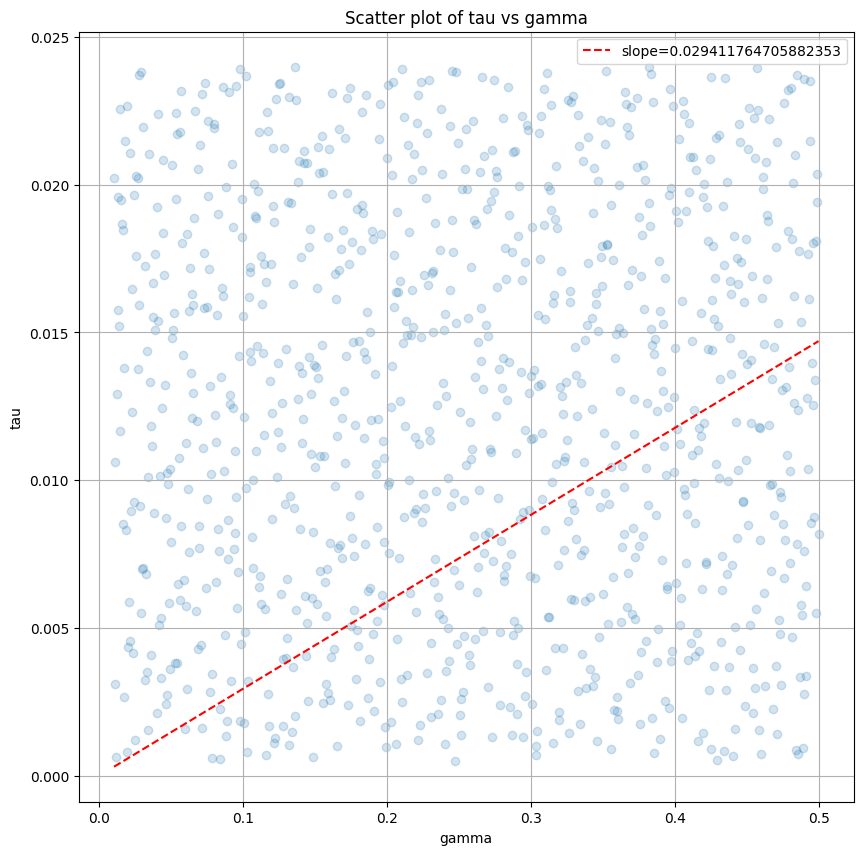

In [6]:
#Plotting
slope=1/34
plt.figure(figsize=(10,10))
plt.scatter(latin_hypercube_sampling_data['gamma'], latin_hypercube_sampling_data['tau'], alpha=0.1)

x_vals = np.linspace(latin_hypercube_sampling_data['gamma'].min(), latin_hypercube_sampling_data['gamma'].max(), 100)
y_vals = slope * x_vals

plt.plot(x_vals, y_vals, color='red', linestyle='--', label=f'slope={slope}')

plt.xlabel('gamma')
plt.ylabel('tau')
plt.title('Scatter plot of tau vs gamma')
plt.legend()
plt.grid(True)
plt.show()